# Explore here

📝 Instrucciones
Sistema de predicción de ventas
Queremos establecer el almacén de nuestra empresa en otra localización y necesitamos estimar el ritmo de las ventas, que desde la creación de la empresa ha ido en aumento, para los próximos meses, a fin de proveer el espacio que necesitaremos.

Paso 1: Carga del conjunto de datos

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from statsmodels.tsa.arima.model import ARIMA
from pmdarima import auto_arima

import warnings
url="https://breathecode.herokuapp.com/asset/internal-link?id=2546&path=sales.csv"

df=pd.read_csv(url)

df.info()


<class 'pandas.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    366 non-null    str    
 1   sales   366 non-null    float64
dtypes: float64(1), str(1)
memory usage: 5.8 KB


convertir fecha  en formato fecha

In [2]:
df["date"] = pd.to_datetime(df["date"])
df = df.set_index("date")

df.head()

,sales
date,
2022-09-03 17:10:08.079328,55.292157
2022-09-04 17:10:08.079328,53.803211
2022-09-05 17:10:08.079328,58.141693
2022-09-06 17:10:08.079328,64.530899
2022-09-07 17:10:08.079328,66.013633


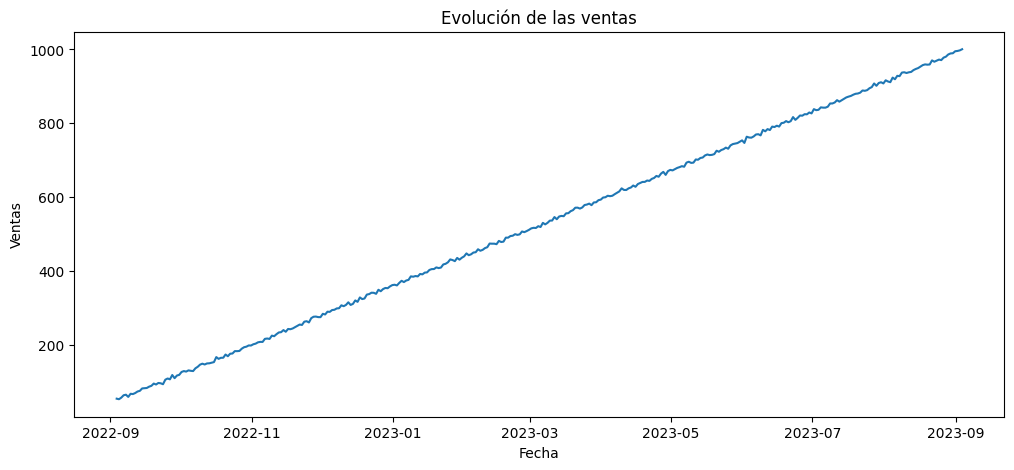

In [3]:
plt.figure(figsize=(12, 5))
plt.plot(df.index, df)
plt.title("Evolución de las ventas")
plt.xlabel("Fecha")
plt.ylabel("Ventas")
plt.show()

Conclusiones:
La serie temporal tiene una frecuencia diaria, además se visualiza una tendencia ascendente.


Paso 2: Construye y analiza la serie temporal

Descomposición de una sserie temporal, se utiliza period=30 para ver patrones cada 30 días 

In [4]:
decomposition = seasonal_decompose(df["sales"], period=30)
decomposition

Análisis de tendencia

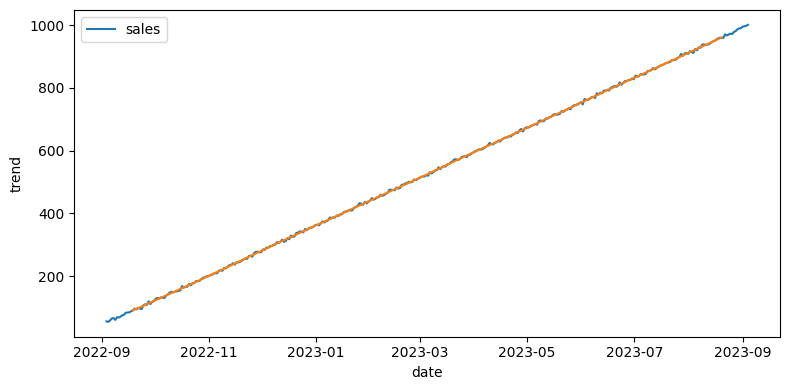

In [5]:
trend = decomposition.trend

fig, axis = plt.subplots(figsize = (8, 4))

sns.lineplot(data = df)
sns.lineplot(data = trend)

plt.tight_layout()

plt.show()

Conclusiones:

La línea naranja representa la tendencia de la serie temporal de ventas.
Se visualiza que la tendencia coincide con los datos originales de ventas, esto quiere decir que hay un crecimiento constante en ventas a lo largo del tiempo y hay poco ruido en los datos.

Análisis de estacionalidad

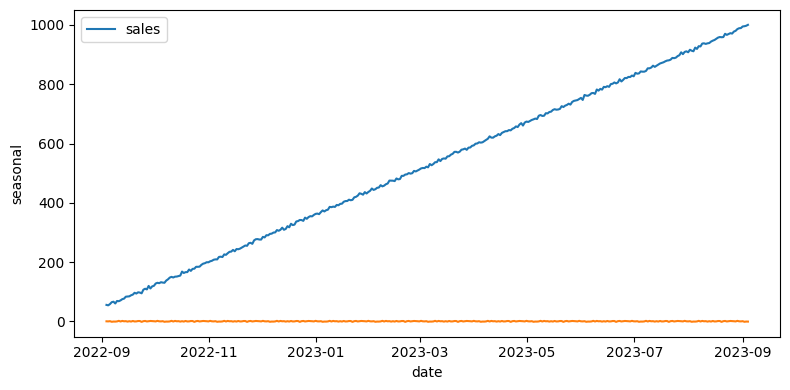

In [6]:
seasonal = decomposition.seasonal

fig, axis = plt.subplots(figsize = (8, 4))

sns.lineplot(data = df) # Representa las ventas
sns.lineplot(data = seasonal)

plt.tight_layout()

plt.show()

Conclusiones:

La estaacionalidad es muy baja por lo que se puede decir que no hay un patrón repetitivo en ventas.
En esta serie temporal predomina la tendencia ascendente. Además, hay poco ruido en los datos.

Análisis de estacionariedad

**Prueba de Dickey-Fuller** (*Dickey-Fuller test*)

In [7]:
def test_stationarity(timeseries):
    print("Resultados de la prueba de Dickey-Fuller:")
    dftest = adfuller(timeseries, autolag = "AIC")
    dfoutput = pd.Series(dftest[0:4], index = ["Test Statistic", "p-value", "#Lags Used", "Number of Observations Used"])
    for key,value in dftest[4].items():
        dfoutput["Critical Value (%s)"%key] = value
    return dfoutput

In [8]:
test_stationarity(df["sales"])

Resultados de la prueba de Dickey-Fuller:


Test Statistic                   0.545414
p-value                          0.986190
#Lags Used                      13.000000
Number of Observations Used    352.000000
Critical Value (1%)             -3.449065
Critical Value (5%)             -2.869786
Critical Value (10%)            -2.571163
dtype: float64

Conclusiones:
El valor p es mayor a 0.05 por lo que se interpreta que la serie no es estacionaria.

Paso 3: Entrena un ARIMA

In [9]:
# Diferenciación de primer orden
df_diff1 = df["sales"].diff().dropna()

Análisis ACF y PACF

- De ACF q = 1,
- De PACF p = 1.

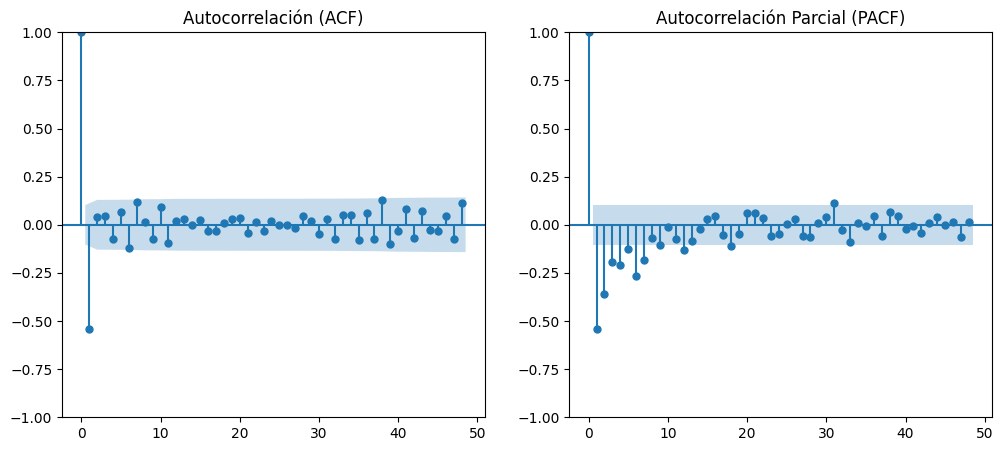

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# ACF para determinar q
plot_acf(df_diff1, lags=48, ax=ax[0])
ax[0].set_title("Autocorrelación (ACF)")

# PACF para determinar p
plot_pacf(df_diff1, lags=48, ax=ax[1])
ax[1].set_title("Autocorrelación Parcial (PACF)")

plt.show()

Separar train y test

In [11]:
train_size = int(len(df) * 0.8)

train = df["sales"][:train_size]
test = df["sales"][train_size:]

print("Train:", train.shape)
print("Test:", test.shape)

Train: (292,)
Test: (74,)


In [12]:
p = 1
d = 1
q = 1

modelo_arima = ARIMA(train, order=(p, d, q))
resultado_arima = modelo_arima.fit()

/home/vscode/.local/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/vscode/.local/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/vscode/.local/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


Conclusiones:
- Se entrenó el modelo ARIMA (1,1,1) utilizando conjujnto de train. Se utilizó d=1 debido a que la serie no tiene estacionariedad.
- Se visualiza en el gráfico que se ajusta bastante bien a los valores reales del test, ya que ambas se ven muy similares.
- Se interpreta que el modelo logra coger correctamente el comportamiento ascendente de los valores de ventas del periodo evaluado.



Paso 4: Predice con el conjunto de test

In [13]:
# Predicción para los 74 días del conjunto de test
predicciones = resultado_arima.forecast(steps=len(test))
predicciones

2023-06-22 17:10:08.079328    808.508796
2023-06-23 17:10:08.079328    811.063413
2023-06-24 17:10:08.079328    813.618029
2023-06-25 17:10:08.079328    816.172645
2023-06-26 17:10:08.079328    818.727260
                                 ...    
2023-08-30 17:10:08.079328    984.776003
2023-08-31 17:10:08.079328    987.330580
2023-09-01 17:10:08.079328    989.885157
2023-09-02 17:10:08.079328    992.439733
2023-09-03 17:10:08.079328    994.994308
Freq: D, Name: predicted_mean, Length: 74, dtype: float64

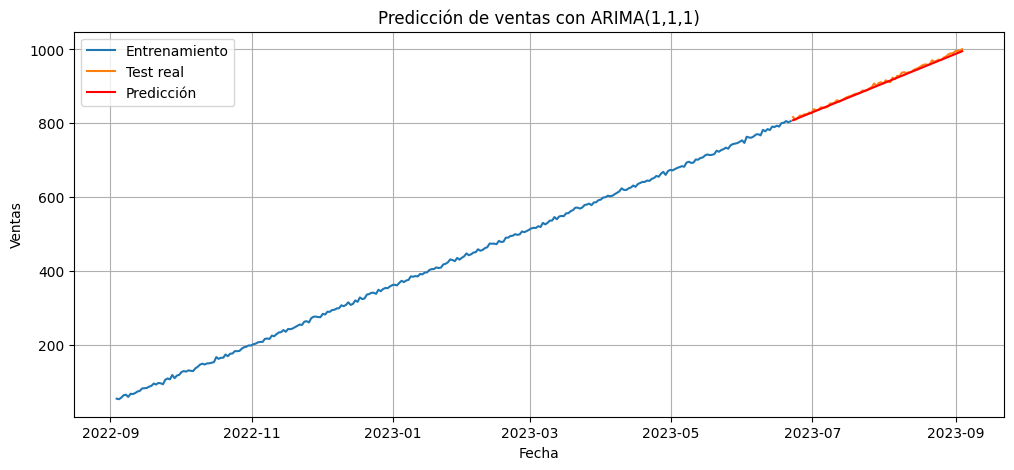

In [14]:
plt.figure(figsize=(12,5))

plt.plot(train, label="Entrenamiento")
plt.plot(test, label="Test real")
plt.plot(predicciones, label="Predicción", color="red")

plt.title("Predicción de ventas con ARIMA(1,1,1)")
plt.xlabel("Fecha")
plt.ylabel("Ventas")
plt.legend()
plt.grid(True)
plt.show()

### Entrenamiento automático del modelo

In [15]:
# Entrenamiento automático con auto_arima usando solo train
model = auto_arima(
    train,
    seasonal=True,
    trace=True,
    m=12
)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[12] intercept   : AIC=1483.238, Time=1.32 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=1675.428, Time=0.01 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=1579.885, Time=0.52 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=1477.110, Time=0.71 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=1763.761, Time=0.02 sec
 ARIMA(0,1,1)(0,0,0)[12] intercept   : AIC=1475.165, Time=0.11 sec
 ARIMA(0,1,1)(1,0,0)[12] intercept   : AIC=1477.106, Time=0.96 sec
 ARIMA(0,1,1)(1,0,1)[12] intercept   : AIC=1478.877, Time=1.28 sec
 ARIMA(1,1,1)(0,0,0)[12] intercept   : AIC=1475.512, Time=0.50 sec
 ARIMA(0,1,2)(0,0,0)[12] intercept   : AIC=1475.495, Time=0.79 sec
 ARIMA(1,1,0)(0,0,0)[12] intercept   : AIC=1578.564, Time=0.15 sec
 ARIMA(1,1,2)(0,0,0)[12] intercept   : AIC=1479.028, Time=0.49 sec
 ARIMA(0,1,1)(0,0,0)[12]             : AIC=1762.924, Time=0.06 sec

Best model:  ARIMA(0,1,1)(0,0,0)[12] intercept
Total fit time: 6.947 seconds


#### Predicción del modelo

In [16]:
forecast = model.predict(len(test))
forecast

2023-06-22 17:10:08.079328    810.107776
2023-06-23 17:10:08.079328    812.706154
2023-06-24 17:10:08.079328    815.304531
2023-06-25 17:10:08.079328    817.902909
2023-06-26 17:10:08.079328    820.501287
                                 ...    
2023-08-30 17:10:08.079328    989.395832
2023-08-31 17:10:08.079328    991.994210
2023-09-01 17:10:08.079328    994.592587
2023-09-02 17:10:08.079328    997.190965
2023-09-03 17:10:08.079328    999.789343
Freq: D, Length: 74, dtype: float64

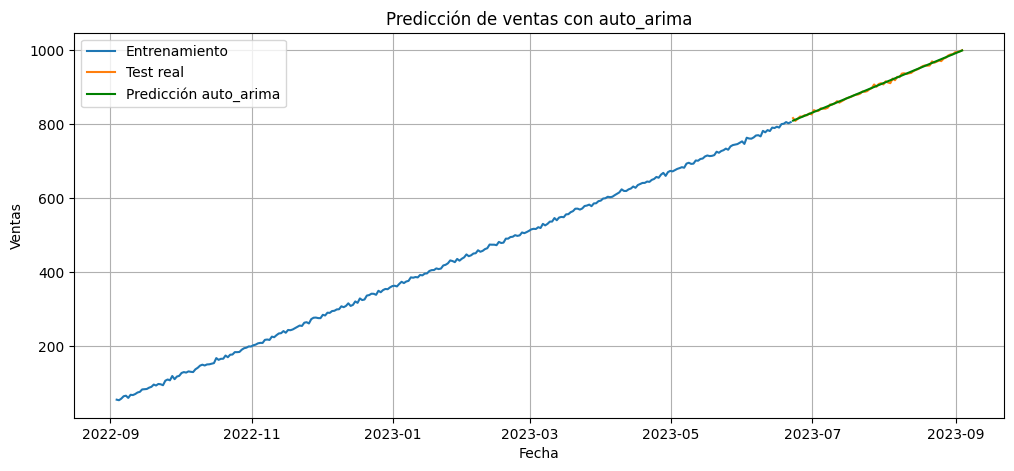

In [17]:
plt.figure(figsize=(12, 5))

plt.plot(train, label="Entrenamiento")
plt.plot(test, label="Test real")
plt.plot(test.index, forecast, label="Predicción auto_arima", color="green")

plt.title("Predicción de ventas con auto_arima")
plt.xlabel("Fecha")
plt.ylabel("Ventas")
plt.legend()
plt.grid(True)
plt.show()

Conclusiones:

Se utilizó auto_arima para buscar automáticamente una mejor parametrización del modelo. La predicción se comparó con el conjunto test.
El modelo genera una predicción creciente en ventas, coherente con el comportamiento inicial del dataset.
